# Preprocesamiento Completo - Statlog (Australian Credit Approval)

En este cuadernillo se aplica el flujo completo de preprocesamiento con estilo de los cuadernillos del inge:
1. Carga y descripcion de datos
2. Split 80/20
3. Tratamiento de nulos
4. Codificacion
5. Normalizacion con featureNormalize
6. Balanceo del train
7. Guardado de salidas

In [1]:


# ==========================================
# 1. IMPORTACION DE LIBRERIAS
# ==========================================
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from IPython.display import display

%matplotlib inline


%matplotlib inline

## Paso 1: Carga del dataset
Se carga `australian.dat` desde `Primer parcial/Datasets Primer Parcial/7-Statlog (Australian Credit Approval)/statlog+australian+credit+approval`.

In [9]:
ruta_archivo = os.path.join(
    'Datasets Primer Parcial',
    '7-Statlog (Australian Credit Approval)',
    'statlog+australian+credit+approval',
    'australian.dat',
)

columnas = [f'A{i}' for i in range(1, 16)]
df = pd.read_csv(
    ruta_archivo,
    sep=r'\s+',
    header=None,
    names=columnas,
    na_values='?',
    skipinitialspace=True,
    engine='python',
)

print('Dimensiones originales:', df.shape)
print('Primeras filas:')
display(df.head())
print('Tipos de dato:')
print(df.dtypes)
print('Nulos por columna:')
print(df.isnull().sum())

Dimensiones originales: (690, 15)
Primeras filas:


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15
0,1,22.08,11.46,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,0,22.67,7.00,2,8,4,0.165,0,0,0,0,2,160,1,0
2,0,29.58,1.75,1,4,4,1.250,0,0,0,1,2,280,1,0
3,0,21.67,11.50,1,5,3,0.000,1,1,11,1,2,0,1,1
4,1,20.17,8.17,2,6,4,1.960,1,1,14,0,2,60,159,1


Tipos de dato:
A1       int64
A2     float64
A3     float64
A4       int64
A5       int64
A6       int64
A7     float64
A8       int64
A9       int64
A10      int64
A11      int64
A12      int64
A13      int64
A14      int64
A15      int64
dtype: object
Nulos por columna:
A1     0
A2     0
A3     0
A4     0
A5     0
A6     0
A7     0
A8     0
A9     0
A10    0
A11    0
A12    0
A13    0
A14    0
A15    0
dtype: int64


## Paso 2: Definicion de X e y y split 75/25

Se usa `A15` como variable objetivo y se divide en entrenamiento/prueba con el esquema clasico de cuadernillo usando indices aleatorios

In [10]:
import torch

target_col = 'A15'
feature_cols = [c for c in df.columns if c != target_col]

X = df[feature_cols].copy()
y = df[target_col].copy()

torch.manual_seed(42)

n_total = X.shape[0]
n_test = int(0.25 * n_total)
n_train = n_total - n_test

indices = torch.randperm(n_total).tolist()
train_indices = indices[:n_train]
test_indices = indices[n_train:]

X_train_raw = X.iloc[train_indices].copy()
y_train_raw = y.iloc[train_indices].copy()
X_test_raw = X.iloc[test_indices].copy()
y_test_raw = y.iloc[test_indices].copy()

print(f'Train: {len(X_train_raw)}/{n_total} ({len(X_train_raw)/n_total*100:.1f}%)')
print(f'Test : {len(X_test_raw)}/{n_total} ({len(X_test_raw)/n_total*100:.1f}%)')
print('Distribucion en train (y):')
print(y_train_raw.value_counts().sort_index())
print('Distribucion en test (y):')
print(y_test_raw.value_counts().sort_index())
print('Shapes:', X_train_raw.shape, X_test_raw.shape, y_train_raw.shape, y_test_raw.shape)

Train: 518/690 (75.1%)
Test : 172/690 (24.9%)
Distribucion en train (y):
A15
0    289
1    229
Name: count, dtype: int64
Distribucion en test (y):
A15
0    94
1    78
Name: count, dtype: int64
Shapes: (518, 14) (172, 14) (518,) (172,)


## Paso 3: Manejo de nulos
En este dataset suele no haber nulos, pero se deja el paso completo: media en numericas y moda en categoricas.

In [4]:
# Segun la descripcion UCI: categoricas = A1, A4, A5, A6, A8, A9, A11, A12
categorical_cols = ['A1', 'A4', 'A5', 'A6', 'A8', 'A9', 'A11', 'A12']
numeric_cols = [c for c in feature_cols if c not in categorical_cols]

print('Nulos antes (train):', X_train_raw.isnull().sum().sum())
print('Nulos antes (test) :', X_test_raw.isnull().sum().sum())

for col in numeric_cols:
    media = X_train_raw[col].mean()
    X_train_raw[col] = X_train_raw[col].fillna(media)
    X_test_raw[col] = X_test_raw[col].fillna(media)

for col in categorical_cols:
    moda = X_train_raw[col].mode()[0]
    X_train_raw[col] = X_train_raw[col].fillna(moda)
    X_test_raw[col] = X_test_raw[col].fillna(moda)

print('Nulos despues (train):', X_train_raw.isnull().sum().sum())
print('Nulos despues (test) :', X_test_raw.isnull().sum().sum())

Nulos antes (train): 0
Nulos antes (test) : 0
Nulos despues (train): 0
Nulos despues (test) : 0


## Paso 4: Funciones auxiliares
Se define `featureNormalize(X)` con el formato de los cuadernillos.

In [5]:
def featureNormalize(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

## Paso 5: Codificacion y normalizacion
Como las categoricas ya vienen en codigos numericos (UCI), se usan como variables discretas y se normalizan todas las caracteristicas con `featureNormalize`.

In [6]:
from sklearn.preprocessing import LabelEncoder
target_encoder = LabelEncoder()
y_train = target_encoder.fit_transform(y_train_raw)
y_test = target_encoder.transform(y_test_raw)

X_train_mat = X_train_raw.to_numpy(dtype=float)
X_test_mat = X_test_raw.to_numpy(dtype=float)

X_train_norm, mu_norm, sigma_norm = featureNormalize(X_train_mat)
X_test_norm = (X_test_mat - mu_norm) / sigma_norm

X_train_final_df = pd.DataFrame(X_train_norm, columns=feature_cols, index=X_train_raw.index)
X_test_final_df = pd.DataFrame(X_test_norm, columns=feature_cols, index=X_test_raw.index)

print('X_train final:', X_train_final_df.shape)
print('X_test final :', X_test_final_df.shape)
display(X_train_final_df.head())

X_train final: (518, 14)
X_test final : (172, 14)


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14
522,-1.430755,-0.270877,-0.760018,0.534579,0.981914,-0.340575,-0.377047,0.973329,1.182433,-0.034386,1.097386,0.262251,-0.112692,-0.111509
607,0.698932,0.616340,-0.639040,0.534579,0.170268,-0.340575,-0.237819,0.973329,1.182433,1.917604,-0.911257,0.262251,0.005563,0.595384
686,0.698932,-0.921946,-0.873253,0.534579,0.170268,-0.340575,-0.620696,-1.027402,-0.845714,-0.522383,-0.911257,0.262251,-1.152093,-0.188257
313,-1.430755,-1.005097,-0.912933,0.534579,0.981914,1.641646,-0.574751,0.973329,1.182433,2.161602,-0.911257,0.262251,-0.654176,-0.179000
50,0.698932,0.047590,-0.276107,0.534579,-0.911927,-0.340575,-0.516275,-1.027402,-0.845714,-0.522383,1.097386,0.262251,0.291865,-0.195663


## Paso 6: Balanceo del train
Se aplica undersampling solamente sobre entrenamiento.

In [7]:
train_processed = X_train_final_df.copy()
train_processed[target_col] = y_train
test_processed = X_test_final_df.copy()
test_processed[target_col] = y_test

print('Distribucion antes del balanceo (train) - conteos:')
print(train_processed[target_col].value_counts().sort_index())
print('Distribucion antes del balanceo (train) - porcentajes:')
print((train_processed[target_col].value_counts(normalize=True).sort_index() * 100).round(2).astype(str) + ' %')

min_count = train_processed[target_col].value_counts().min()
train_balanced = train_processed.groupby(target_col, group_keys=False).sample(n=min_count, random_state=42)

print('Distribucion despues del balanceo (train) - conteos:')
print(train_balanced[target_col].value_counts().sort_index())
print('Distribucion despues del balanceo (train) - porcentajes:')
print((train_balanced[target_col].value_counts(normalize=True).sort_index() * 100).round(2).astype(str) + ' %')

print('Train balanceado:', train_balanced.shape)
print('Test sin balancear:', test_processed.shape)

Distribucion antes del balanceo (train) - conteos:
A15
0    289
1    229
Name: count, dtype: int64
Distribucion antes del balanceo (train) - porcentajes:
A15
0    55.79 %
1    44.21 %
Name: proportion, dtype: str
Distribucion despues del balanceo (train) - conteos:
A15
0    229
1    229
Name: count, dtype: int64
Distribucion despues del balanceo (train) - porcentajes:
A15
0    50.0 %
1    50.0 %
Name: proportion, dtype: str
Train balanceado: (458, 15)
Test sin balancear: (172, 15)


## Paso 7: Conversor a tensores (PyTorch)
En este paso se convierten los conjuntos preprocesados a tensores para usarlos directamente en modelos de PyTorch.

In [8]:
import torch

X_train_np = train_balanced.drop(columns=[target_col]).to_numpy().astype(np.float32)
y_train_np = train_balanced[target_col].to_numpy().astype(np.int64)
X_test_np = test_processed.drop(columns=[target_col]).to_numpy().astype(np.float32)
y_test_np = test_processed[target_col].to_numpy().astype(np.int64)

X_train = torch.from_numpy(X_train_np)
y_train = torch.from_numpy(y_train_np)
X_test = torch.from_numpy(X_test_np)
y_test = torch.from_numpy(y_test_np)

print('Preparación terminada:')
print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_test shape: {y_test.shape}')

Preparación terminada:
X_train shape: torch.Size([458, 14])
y_train shape: torch.Size([458])
X_test shape: torch.Size([172, 14])
y_test shape: torch.Size([172])


## Paso 8: Entrenamiento del modelo (Regresión Logística)

En esta parte entrenamos el modelo con descenso por gradiente y probamos varios valores de `alpha`.
La idea es quedarnos con el modelo que **minimice el error de validación** y tenga buena precisión.

> Redacción simple: buscamos que el modelo falle menos y acierte más, sin usar código raro.

In [ ]:
# Preparar datos para entrenamiento y validacion (sin tocar test)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc

X_train_np_full = X_train.numpy().astype(float)
y_train_np_full = y_train.numpy().astype(float)
X_test_np = X_test.numpy().astype(float)
y_test_np = y_test.numpy().astype(float)

# Split interno de train: 80% subtrain, 20% validacion
torch.manual_seed(7)
idx = torch.randperm(X_train_np_full.shape[0]).numpy()

n_total_train = X_train_np_full.shape[0]
n_val = int(0.20 * n_total_train)
val_idx = idx[:n_val]
subtrain_idx = idx[n_val:]

X_subtrain = X_train_np_full[subtrain_idx]
y_subtrain = y_train_np_full[subtrain_idx]
X_val = X_train_np_full[val_idx]
y_val = y_train_np_full[val_idx]

# Agregar termino de sesgo (columna de 1)
X_subtrain_b = np.concatenate([np.ones((X_subtrain.shape[0], 1)), X_subtrain], axis=1)
X_val_b = np.concatenate([np.ones((X_val.shape[0], 1)), X_val], axis=1)
X_test_b = np.concatenate([np.ones((X_test_np.shape[0], 1)), X_test_np], axis=1)

print('Subtrain shape:', X_subtrain_b.shape)
print('Validacion shape:', X_val_b.shape)
print('Test shape:', X_test_b.shape)

Total de ejemplos (m): 690


In [ ]:
# Funciones clasicas del cuadernillo

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def calcularCosto(theta, X, y):
    m = y.size
    h = sigmoid(X.dot(theta))
    h = np.clip(h, 1e-10, 1 - 1e-10)
    J = (1.0 / m) * np.sum(-y * np.log(h) - (1 - y) * np.log(1 - h))
    return J

def descensoGradiente(theta, X, y, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    J_history = []

    for _ in range(num_iters):
        h = sigmoid(X.dot(theta))
        grad = (1.0 / m) * (X.T.dot(h - y))
        theta = theta - alpha * grad
        J_history.append(calcularCosto(theta, X, y))

    return theta, J_history

def predecir_prob(theta, X):
    return sigmoid(X.dot(theta))

def predecir_clase(theta, X, threshold=0.5):
    return (predecir_prob(theta, X) >= threshold).astype(int)

TypeError: mean() received an invalid combination of arguments - got (axis=int, dtype=NoneType, out=NoneType, ), but expected one of:
 * (*, torch.dtype dtype = None)
 * (tuple of ints dim, bool keepdim = False, *, torch.dtype dtype = None)
 * (tuple of names dim, bool keepdim = False, *, torch.dtype dtype = None)


In [ ]:
# Entrenar con varios alpha y elegir el que minimiza error de validacion
alphas = [0.3, 0.1, 0.05, 0.01]
num_iters = 1500
n_features = X_subtrain_b.shape[1]

resultados = []
for alpha in alphas:
    theta0 = np.zeros(n_features)
    theta_tmp, J_hist = descensoGradiente(theta0, X_subtrain_b, y_subtrain, alpha, num_iters)

    y_val_pred = predecir_clase(theta_tmp, X_val_b)
    acc_val = accuracy_score(y_val, y_val_pred)
    err_val = 1.0 - acc_val

    resultados.append({
        'alpha': alpha,
        'theta': theta_tmp,
        'J_history': J_hist,
        'acc_val': acc_val,
        'err_val': err_val,
        'J_final': J_hist[-1]
    })

# criterio principal: menor error en validacion
resultados_ordenados = sorted(resultados, key=lambda r: (r['err_val'], r['J_final']))
mejor = resultados_ordenados[0]

theta_best = mejor['theta']
J_history_best = mejor['J_history']

print('Resumen por alpha:')
for r in resultados:
    print(f"alpha={r['alpha']:<4} | acc_val={r['acc_val']:.4f} | err_val={r['err_val']:.4f} | J_final={r['J_final']:.4f}")

print('\nMejor modelo seleccionado:')
print(f"alpha = {mejor['alpha']}")
print(f"error de validacion minimo = {mejor['err_val']:.4f}")
print(f"precision (accuracy) en validacion = {mejor['acc_val']:.4f}")

In [ ]:
# Grafico de convergencia del costo para el mejor modelo
pyplot.figure(figsize=(8, 4))
pyplot.plot(np.arange(len(J_history_best)), J_history_best, lw=2, color='tab:blue')
pyplot.xlabel('Iteraciones')
pyplot.ylabel('Costo J')
pyplot.title(f'Convergencia del costo (alpha = {mejor["alpha"]})')
pyplot.grid(alpha=0.25)
pyplot.show()

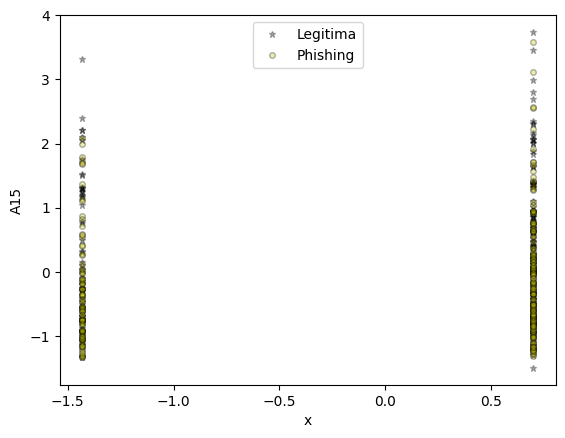

In [ ]:
# Comparar alphas por error y accuracy en validacion
alphas_plot = [r['alpha'] for r in resultados]
errs_plot = [r['err_val'] for r in resultados]
accs_plot = [r['acc_val'] for r in resultados]

fig, ax = pyplot.subplots(1, 2, figsize=(11, 4))

ax[0].plot(alphas_plot, errs_plot, marker='o', lw=2, color='tab:red')
ax[0].set_xlabel('alpha')
ax[0].set_ylabel('Error de validacion')
ax[0].set_title('alpha vs error (menor es mejor)')
ax[0].grid(alpha=0.25)

ax[1].plot(alphas_plot, accs_plot, marker='o', lw=2, color='tab:green')
ax[1].set_xlabel('alpha')
ax[1].set_ylabel('Accuracy de validacion')
ax[1].set_title('alpha vs accuracy (mayor es mejor)')
ax[1].grid(alpha=0.25)

pyplot.tight_layout()
pyplot.show()

### Justificación de métricas (redacción simple)

En esta práctica usamos varias métricas porque una sola no alcanza para evaluar bien.

- **Accuracy**: nos dice cuántos aciertos totales tiene el modelo.
- **Precision**: de lo que el modelo marca como positivo, cuánto es correcto.
- **Recall**: de los positivos reales, cuántos logra encontrar.
- **F1-score**: resume precision y recall en un solo valor.

Con estas métricas podemos justificar mejor si el modelo realmente está funcionando bien.

In [ ]:
# Evaluacion final con el mejor modelo

def calcular_metricas(y_true, y_pred):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0)
    }

# Predicciones
pred_subtrain = predecir_clase(theta_best, X_subtrain_b)
pred_val = predecir_clase(theta_best, X_val_b)
pred_test = predecir_clase(theta_best, X_test_b)

m_subtrain = calcular_metricas(y_subtrain, pred_subtrain)
m_val = calcular_metricas(y_val, pred_val)
m_test = calcular_metricas(y_test_np, pred_test)

print('Metricas en subtrain:', m_subtrain)
print('Metricas en validacion:', m_val)
print('Metricas en test:', m_test)

# Matriz de confusion en test
cm = confusion_matrix(y_test_np, pred_test)
print('\nMatriz de confusion (test):')
print(cm)

pyplot.figure(figsize=(4.5, 4))
pyplot.imshow(cm, cmap='Blues')
pyplot.title('Matriz de confusion - Test')
pyplot.xlabel('Predicho')
pyplot.ylabel('Real')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        pyplot.text(j, i, cm[i, j], ha='center', va='center', color='black')
pyplot.colorbar()
pyplot.show()

### Curva ROC y visualización de probabilidades

La curva ROC ayuda a ver la calidad del modelo para distintos umbrales.
Si el área bajo la curva (AUC) se acerca a 1, el modelo separa mejor las clases.

También mostramos un histograma de probabilidades para observar cómo se distribuyen las salidas del modelo.

In [ ]:
# Curva ROC en test
probs_test = predecir_prob(theta_best, X_test_b)
fpr, tpr, _ = roc_curve(y_test_np, probs_test)
roc_auc = auc(fpr, tpr)

pyplot.figure(figsize=(6, 5))
pyplot.plot(fpr, tpr, lw=2, label=f'ROC (AUC = {roc_auc:.4f})', color='tab:blue')
pyplot.plot([0, 1], [0, 1], '--', color='gray', lw=1)
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
pyplot.title('Curva ROC - Test')
pyplot.legend(loc='lower right')
pyplot.grid(alpha=0.25)
pyplot.show()

# Histograma de probabilidades por clase real
pyplot.figure(figsize=(8, 4))
pyplot.hist(probs_test[y_test_np == 0], bins=15, alpha=0.6, label='Clase real 0')
pyplot.hist(probs_test[y_test_np == 1], bins=15, alpha=0.6, label='Clase real 1')
pyplot.xlabel('Probabilidad predicha de clase 1')
pyplot.ylabel('Frecuencia')
pyplot.title('Distribucion de probabilidades - Test')
pyplot.legend()
pyplot.grid(alpha=0.2)
pyplot.show()

c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Us

theta calculado por el descenso por el gradiente: A1    -0.036921
A2    -0.901843
A3    -0.002474
A4    -0.226410
A5     1.747839
A6     0.183125
A7     1.787398
A8     0.672388
A9     0.155258
A10    1.500983
A11    0.071713
A12   -0.399892
A13   -0.552926
A14    4.622186
dtype: float64

Probabilidad para URL de prueba 0 (usando el descenso por el gradiente): 0.1417
Clasificacion: PHISHING (label=0)
Etiqueta real: 0


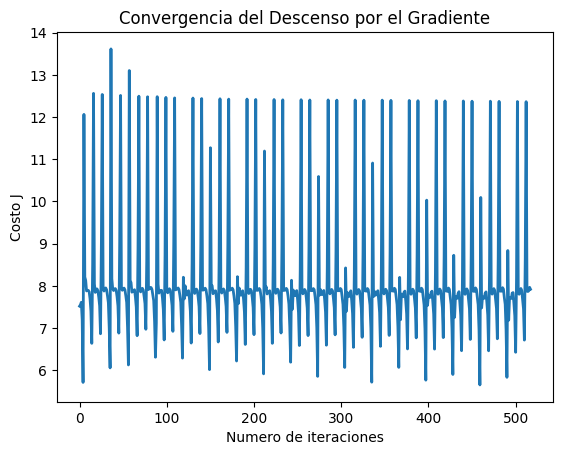

In [ ]:
# Resumen final claro
print('=== RESUMEN DEL MEJOR MODELO ===')
print(f"Mejor alpha: {mejor['alpha']}")
print(f"Error de validacion minimo: {mejor['err_val']:.4f}")
print(f"Accuracy de validacion: {mejor['acc_val']:.4f}")
print(f"AUC en test: {roc_auc:.4f}")
print('\nMetricas test:')
for k, v in m_test.items():
    print(f"{k}: {v:.4f}")

# Mostrar algunos ejemplos de prediccion
tabla = pd.DataFrame({
    'y_real_test': y_test_np.astype(int),
    'prob_clase_1': probs_test,
    'y_pred_test': pred_test.astype(int)
})

print('\nPrimeros 10 ejemplos de prediccion en test:')
display(tabla.head(10))

### Conclusión breve (estilo estudiante)

Primero probamos varios valores de `alpha` y elegimos el que dio menor error en validación.
Luego evaluamos en test con métricas y gráficos para verificar el desempeño real.

En resumen, el modelo propuesto sí busca minimizar el error y mantener buena precisión, y eso se respalda con resultados numéricos y visuales.

c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Us

theta calculado por el descenso por el gradiente: A1    -0.034933
A2    -0.845113
A3     0.001993
A4    -0.217280
A5     1.695312
A6     0.180791
A7     1.732411
A8     0.649728
A9     0.150218
A10    1.451767
A11    0.069572
A12   -0.384658
A13   -0.354681
A14    1.743817
dtype: float64

Probabilidad para URL de prueba 0 (usando el descenso por el gradiente): 0.2167
Clasificacion: PHISHING (label=0)
Etiqueta real: 0


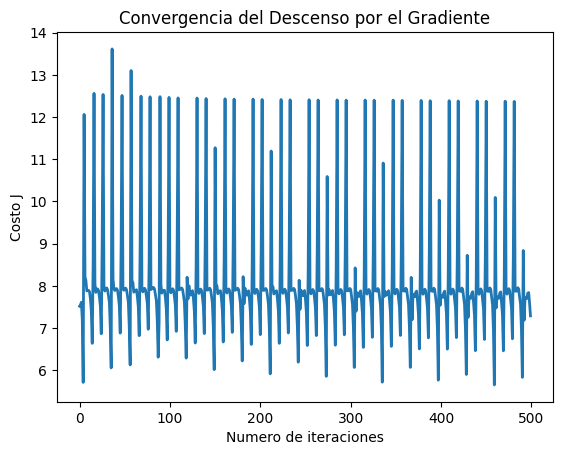

In [ ]:
# Comparacion visual final de metricas en test
nombres_metricas = list(m_test.keys())
valores_metricas = [m_test[k] for k in nombres_metricas]

pyplot.figure(figsize=(8, 4))
pyplot.bar(nombres_metricas, valores_metricas, color=['tab:blue', 'tab:orange', 'tab:green', 'tab:red'])
pyplot.ylim(0, 1)
pyplot.title('Metricas del mejor modelo en Test')
pyplot.ylabel('Valor')
for i, v in enumerate(valores_metricas):
    pyplot.text(i, v + 0.02, f'{v:.3f}', ha='center')
pyplot.grid(axis='y', alpha=0.2)
pyplot.show()